# First Return Problem

Had to google a couple times before i even knew what this was
Disclaimer: Language is Julia

In [21]:
using Random, Statistics, StatsPlots

In [22]:
N = 10_000   
Tmax = 500  
p = 0.5    # Symmetrie  
q = 1 - p
first_returns = fill(-1, N)

10000-element Vector{Int64}:
 -1
 -1
 -1
 -1
 -1
 -1
 -1
 -1
 -1
 -1
  ⋮
 -1
 -1
 -1
 -1
 -1
 -1
 -1
 -1
 -1

In [23]:
for i in 1:N
    x = 0
    for t in 1:Tmax
        x += rand(Bool) ? 1 : -1
        if x == 0 && first_returns[i] == -1
            first_returns[i] = t
            break
        end
    end
end

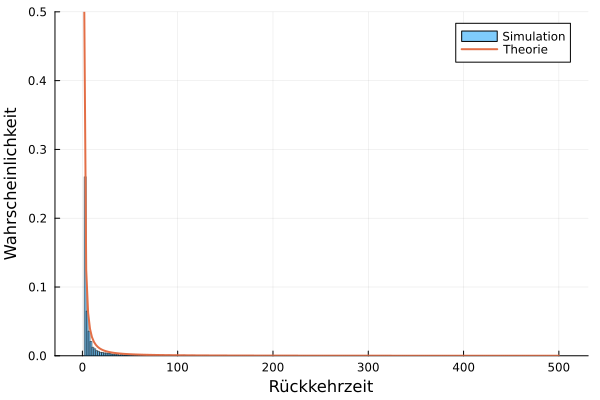

In [24]:
#Anteil zurückgekehrt
return_counts = [count(x -> x ≤ t && x > 0, first_returns) / N for t in 1:Tmax]
plot(1:Tmax, 
    return_counts, 
    label="Simulation", 
    xlabel="Zeit", 
    ylabel="Anteil zurückgekehrt", 
    legend=:bottomright)

#Histogramm Rückkehrzeiten
histogram(first_returns[first_returns .> 0], 
         bins=50, 
         label="Simulation", 
         xlabel="Rückkehrzeit", 
         ylabel="Häufigkeit", 
         legend=:topright)

#P(f_{2n})
function P_first_return(n, p, q)
    m = div(n, 2)
    if isodd(n) || m == 0
        return 0.0
    end
    return (1 / (2m - 1)) * binomial(BigInt(2m), BigInt(m)) * (p * q)^m |> Float64    # musste debuggen lassen weil es gab nen overflow error
end


t_vals = 2:2:Tmax
theory = [P_first_return(t, p, q) for t in t_vals]

#Vergleich mit Theorie
histogram(first_returns[first_returns .> 0],
         bins=t_vals,
         normalize=true, 
         label="Simulation", 
         alpha=0.5, 
         xlabel="Rückkehrzeit", 
         ylabel="Wahrscheinlichkeit")


plot!(t_vals, theory, label="Theorie", lw=2)